# Coupling JCM and Veros

Couple JCM and Veros using JAX-ESM (JEM).

In [1]:
from pathlib import Path
import jax
jax.config.update("jax_enable_x64", False) 
import jax.numpy as jnp
import jcm
from jcm.geometry import Geometry
import jax_datetime as jdt

from jem.tool_scripts.generate_jcm_forcing_and_topography_files import (
    generate_jcm_forcing_and_topography_files,
)
from jem.components import JCM, Veros, SlabOceanModel
from jem.mapping import IdentityRegridder
from jem.mapping import BasicMapper
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

Setting veros.runtime_settings...
Importing core modules
 Using computational backend jax on cpu
  Kernels are compiled during first iteration, be patient
 Runtime settings are now locked



## Choose terrain
In this example, you can specify one of the three configurations, "aquaplanet", "toy_earth", and "capped_earth", when calling the function `modify_jcm_terrain`. Because Veros cannot simulate poles, this example uses a slab model to cap the poles. We choose slab ocean model to be "fake land". Using slab land model currently will yield unrealistic temperature at poles because the albedo of ice and snow is not implemented in idealize setup.

In [2]:
from modify_jcm_terrain import modify_jcm_terrain
external_files = generate_jcm_forcing_and_topography_files()

# There are three choices: "aquaplanet", "toy_earth", and "capped_earth". The outcome will be saved in the folder "data"
terrain_file = modify_jcm_terrain(external_files["terrain"], "toy_earth", "./data")

Using input data directory: "/home/xtt/.cache/jcm".
Check file: /home/xtt/.cache/jcm/terrain_t31.nc... found.
Check file: /home/xtt/.cache/jcm/forcing_t31.nc... found.
Modifying reference jcm terrain file: /home/xtt/.cache/jcm/terrain_t31.nc
Target output file: /home/xtt/projects/project_jax-esm/jax-esm_repo/design-packing-unpacking-coupler/notebooks/JCM_Veros/data/terrain_toy_earth.nc
Loaded xarray metadata
<xarray.Dataset> Size: 75kB
Dimensions:  (lon: 96, lat: 48)
Coordinates:
  * lon      (lon) float64 768B 0.0 3.75 7.5 11.25 ... 345.0 348.8 352.5 356.2
  * lat      (lat) float64 384B -87.16 -83.48 -79.78 ... 79.78 83.48 87.16
    lev      float64 8B ...
Data variables:
    lsm      (lon, lat) float64 37kB ...
    orog     (lon, lat) float64 37kB ...
Attributes:
    CDI:          Climate Data Interface version 1.7.1 (http://mpimet.mpg.de/...
    CDO:          Climate Data Operators version 1.7.1 (http://mpimet.mpg.de/...
    grid_type:    gaussian
    history:      Sun Apr 21 21:26

## Configurations

In [3]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
output_dir = Path("output/JCM_VEROS_SLM").resolve()

output_dir.mkdir(exist_ok=True, parents=True)
one_second = jdt.to_timedelta(1, "second")

## Create Components

### Create Veros

First need to remove `output_veros.*.nc` files, otherwise veros complains.

In [4]:
import glob
import os
files = glob.glob("output_veros.*.nc")
for f in files:
    print(f"Deleting: {f}")
    os.remove(f)

In [5]:
import veros_case_setup
veros_case_setup.land_sea_mask_file = terrain_file
ocn_model = veros_case_setup.VerosCaseSetup()
ocn_model.setup()
Veros.make_jem_compatible(
    ocn_model,
    coupling_timestep=coupling_timestep,
)

Veros path: /home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/veros/__init__.py
Running model setup
Initializing streamfunction method
 Solving for boundary contribution by island 0
 Solving for boundary contribution by island 1
Diffusion grid factor delta_iso1 = 0.010957363360409974


### Create JCM

In [6]:
atm_model = jcm.model.Model(
    start_date=start_datetime,
    geometry=Geometry.from_file(terrain_file),
)

JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
    land_model_active=True,
)

### Create Slab Ocean model

In [7]:
slab_ocn_model=SlabOceanModel(
    start_datetime=start_datetime,
    timestep=coupling_timestep/one_second,
    mask_file=terrain_file ,
    forcing_method=None,
    mask_value=1.0,
)

## Creating Flux and Scalar Exchange between Components

Here we demonstrote the flexibility of JEM: You do not have to use the `BasicMapper` that JEM provides. You can define your own mapping function. In this example, we simply define a function `interaction` as below.

In [8]:
# Creating regridders and mapping
def veros_to_jcm_regridder(arr):
    return jnp.pad(arr, ((0, 0), (4, 4)), constant_values=150)
def jcm_to_veros_regridder(arr):
    return arr[:, 4:-4]

# Note: Remember to return the `coupled_carry` at the end.
def interaction(coupled_carry):
    atm = coupled_carry["atm"]
    ocn = coupled_carry["ocn"]
    slab_ocn = coupled_carry["slab_ocn"]

    # ===== compute wind stress begin =====
    # Tien-Yiao's ad-hoc way to compute wind stress
    # This conveniently demonstrates how the flux computation can be its own
    # function or module
    drag_coefficient = 1e-3 # dimensionless
    air_density = 1.22 # kg / m^3
    wind_x = jcm_to_veros_regridder(atm["derived"]["physics"].surface_flux.u0)
    wind_y = jcm_to_veros_regridder(atm["derived"]["physics"].surface_flux.v0)
    wind_velocity = jnp.sqrt(wind_x**2 + wind_y**2)    
    vs = ocn["state"].variables
    surface_taux = drag_coefficient * air_density * wind_velocity * wind_x
    surface_tauy = drag_coefficient * air_density * wind_velocity * wind_y
    # ===== compute wind stress end =====

    # Mapping
    ocn["forcing"].surface_taux = surface_taux
    ocn["forcing"].surface_tauy = surface_tauy     
    ocn["forcing"].heat_flux = jcm_to_veros_regridder(atm["derived"]["total_heat_flux"])
    ocn["forcing"].freshwater_flux = jcm_to_veros_regridder(atm["derived"]["total_freshwater_flux"])
    ocn["forcing"].wind_x = jcm_to_veros_regridder(atm["derived"]["physics"].surface_flux.u0)
    ocn["forcing"].wind_y = jcm_to_veros_regridder(atm["derived"]["physics"].surface_flux.v0)
    slab_ocn["forcing"].total_heat_flux = atm["derived"]["total_heat_flux"]
    atm["forcing"].sea_surface_temperature = veros_to_jcm_regridder(ocn["derived"]["sea_surface_temperature"])
    atm["forcing"].stl_am = slab_ocn["state"]["sea_surface_temperature"]

    return coupled_carry
    

## Create Coupled Model

In [9]:
model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=ocn_model,
        slab_ocn=slab_ocn_model,
    ),
    mappers=dict(mapper=interaction),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.C

## Run Coupled Model

In [10]:
simulation_interval = jdt.to_timedelta(10, "day")
initial_state, final_state, predictions = model.run(
    workflow=["mapper", "ocn", "atm", "slab_ocn"],
    iterations = int(simulation_interval / coupling_timestep),
    jitted=True,
)

Boundary does not exist. Idealized initial SST will be used.
grid.bmask and SST_clim do share the same mask.
Notice: Climaology SST does not exist. Set relaxation time to inifinity.
Flattened workflow:  mapper, ocn, atm, slab_ocn
The original set_forcing in the VerosSetup object is replaced by this empty set_forcing function. JEM-veros will set the forcing in the step_function.
The original set_forcing in the VerosSetup object is replaced by this empty set_forcing function. JEM-veros will set the forcing in the step_function.
Using method: None


Simulation:   0%|          | 0/10 [00:00<?, ?it/s]

## Output into NetCDF

In [11]:
output_dict = model.predictions_to_xarray(predictions)
for component_name, ds in output_dict.items():
    output_file = output_dir / f"{component_name:s}.nc"
    print("Output file: ", str(output_file))
    ds.to_netcdf(output_file, engine="netcdf4")

Output file:  /home/xtt/projects/project_jax-esm/jax-esm_repo/design-packing-unpacking-coupler/notebooks/JCM_Veros/output/JCM_VEROS_SLM/atm.nc
Output file:  /home/xtt/projects/project_jax-esm/jax-esm_repo/design-packing-unpacking-coupler/notebooks/JCM_Veros/output/JCM_VEROS_SLM/ocn.nc
Output file:  /home/xtt/projects/project_jax-esm/jax-esm_repo/design-packing-unpacking-coupler/notebooks/JCM_Veros/output/JCM_VEROS_SLM/slab_ocn.nc


## Visualization

In [12]:
import matplotlib.pyplot as plt

### Atmosphere

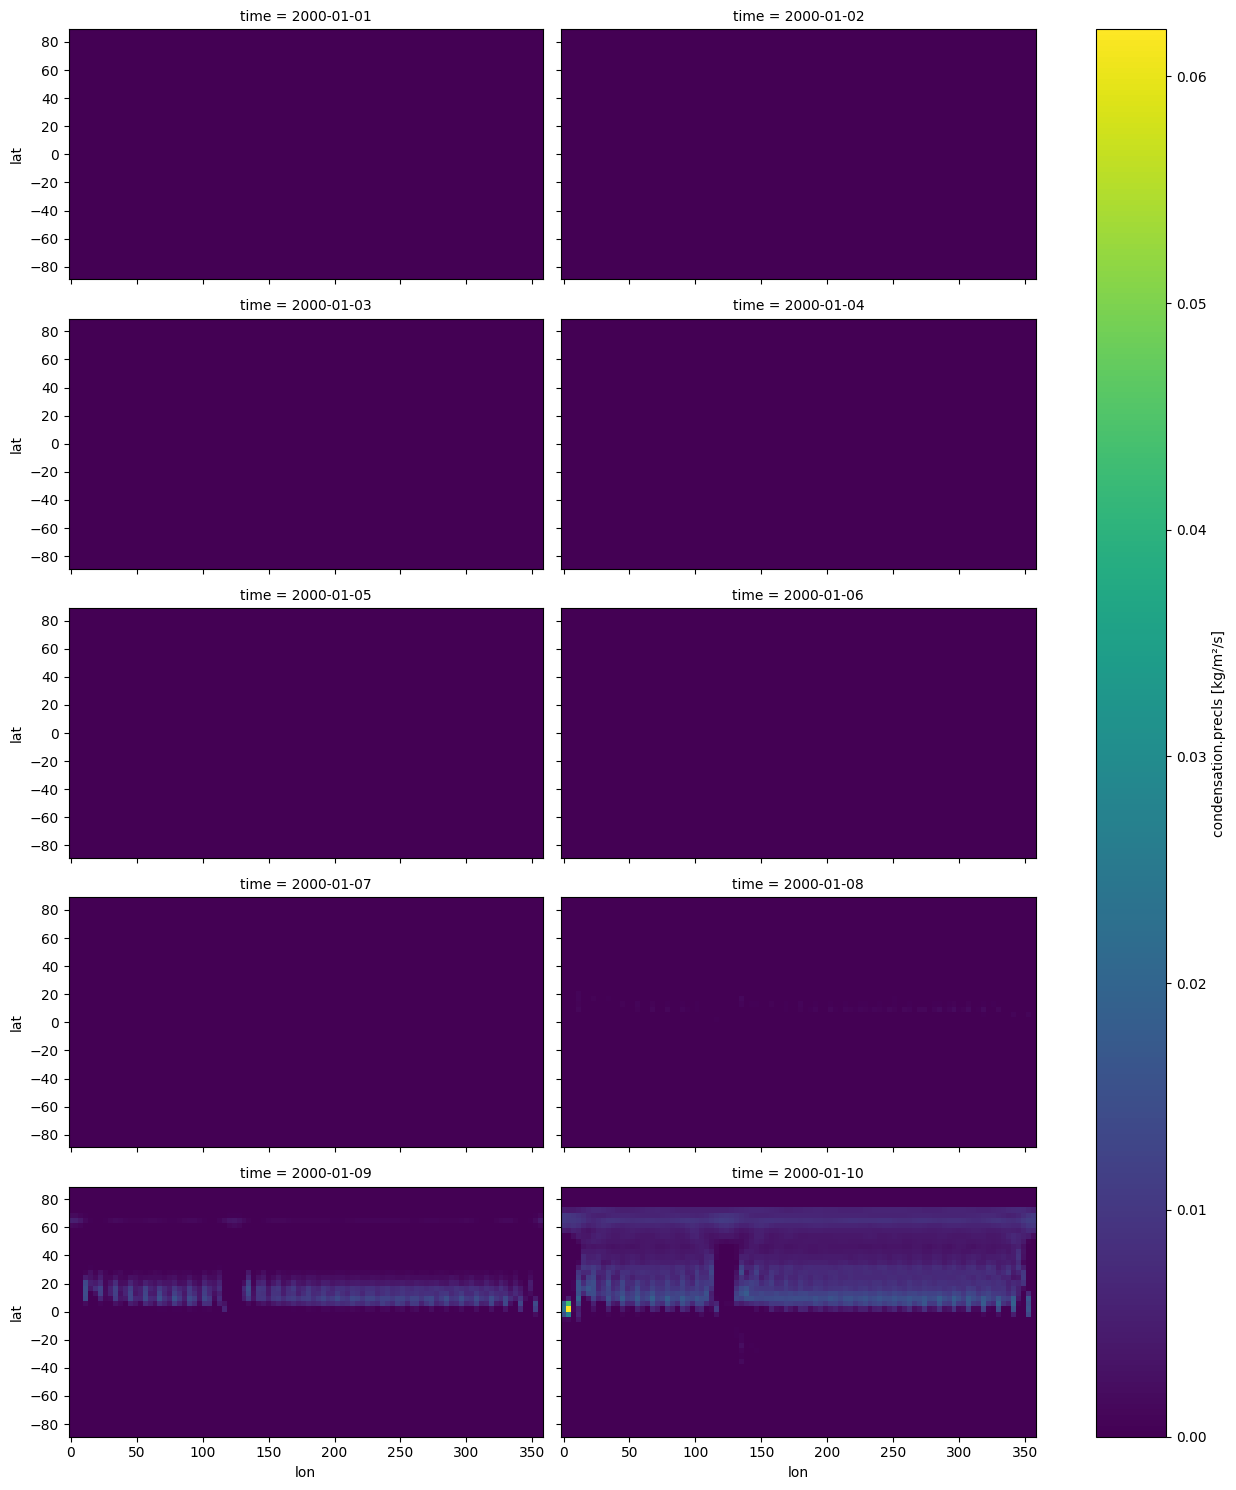

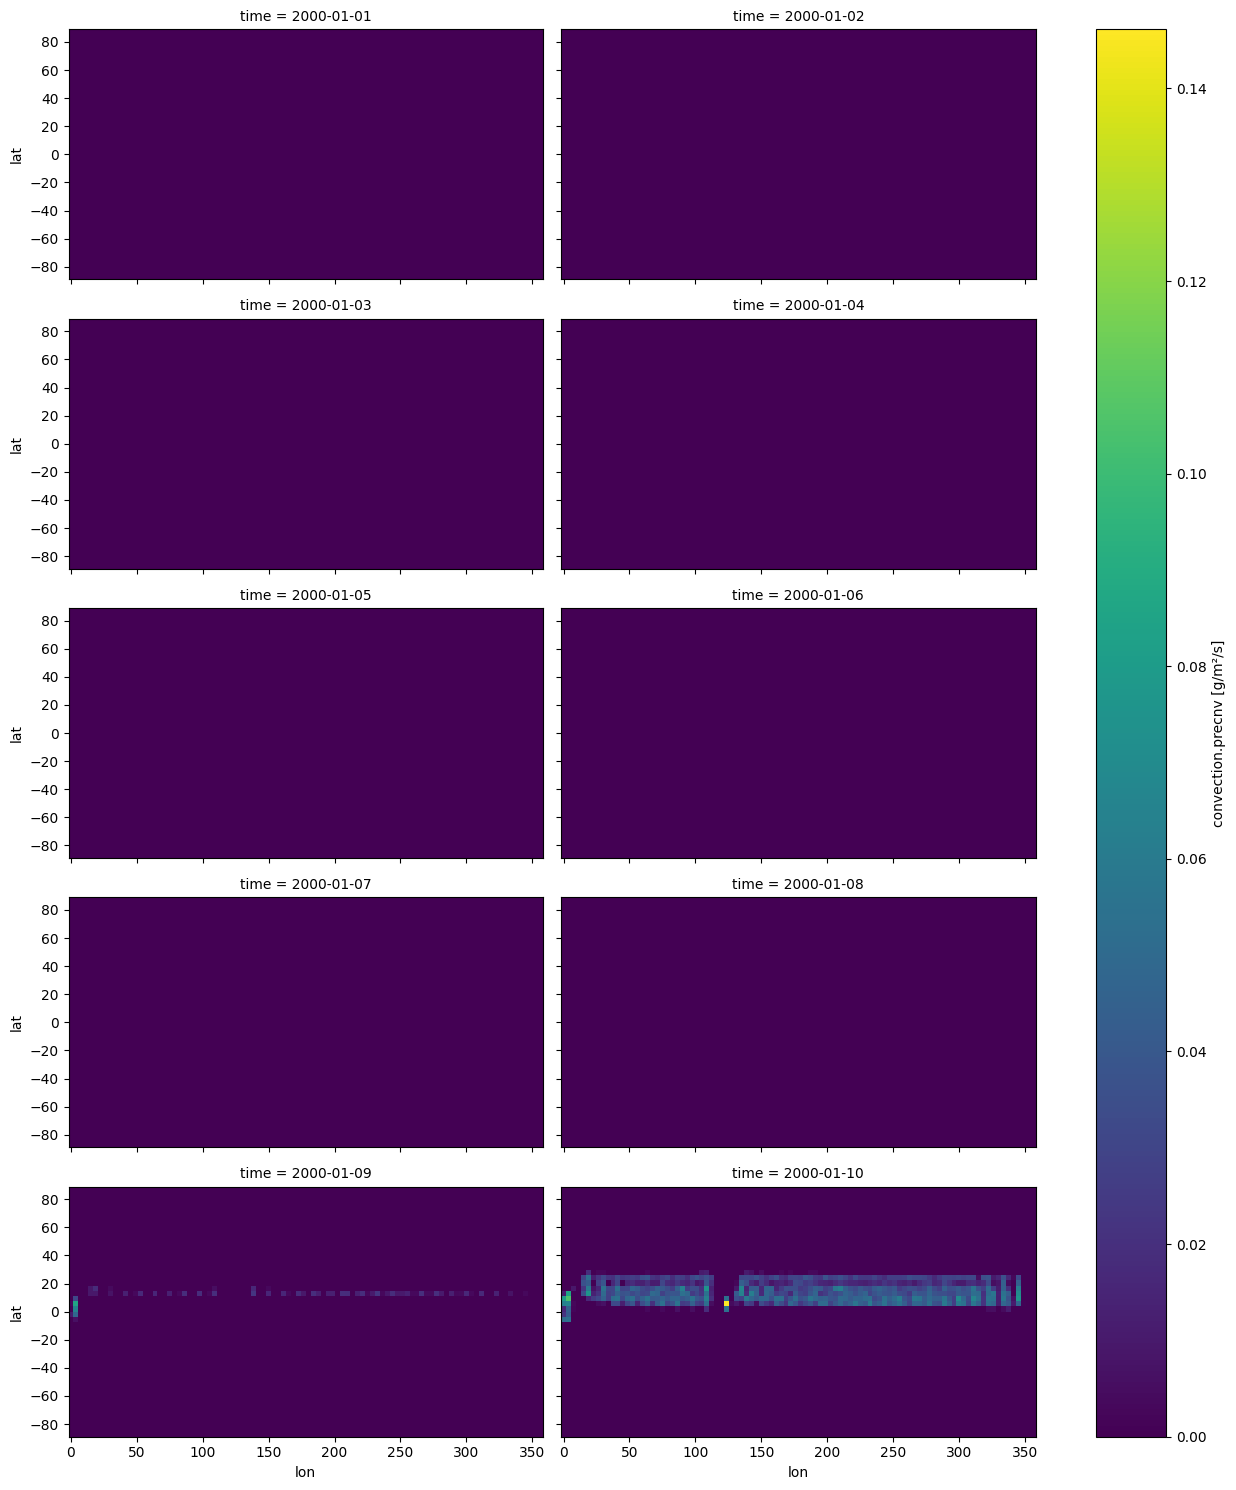

In [13]:
ds = output_dict["atm"]
ds['condensation.precls'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)
ds['convection.precnv'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)

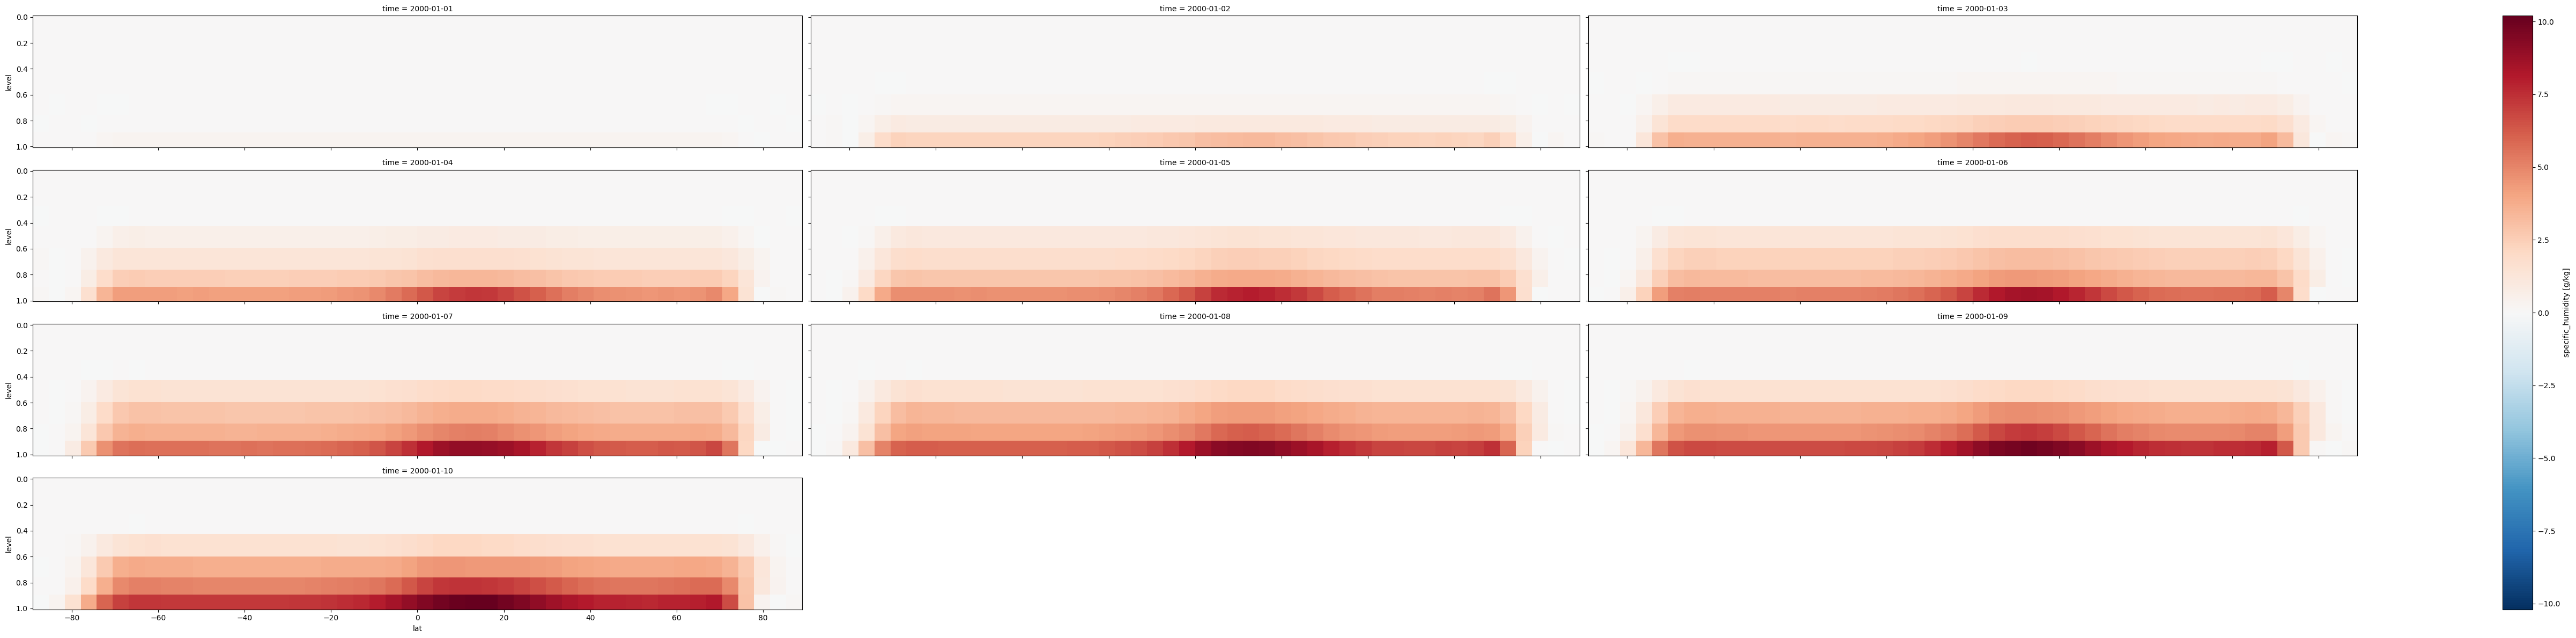

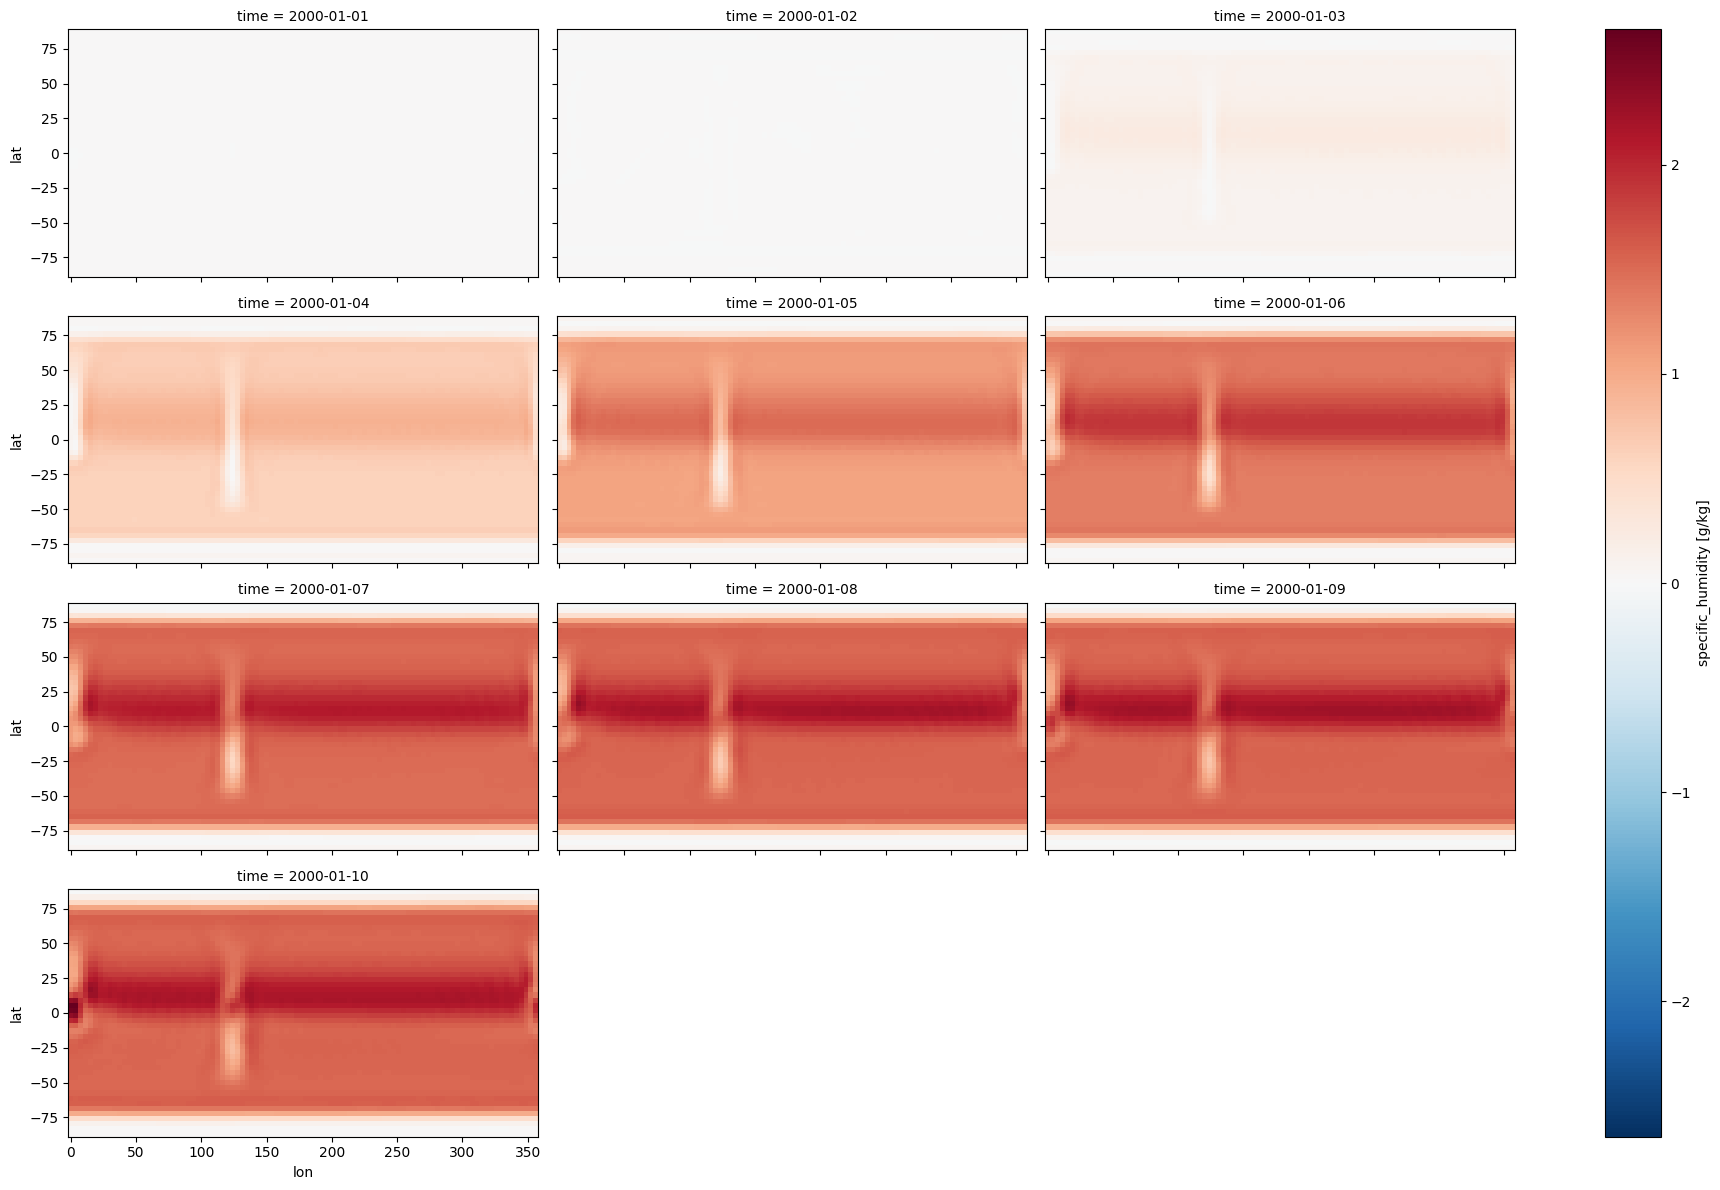

In [14]:
ds['specific_humidity'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
ds['specific_humidity'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

### Ocean

In [15]:
ds = output_dict["ocn"]
print(str(ds))

<xarray.Dataset> Size: 2MB
Dimensions:                  (time: 10, longitude: 96, latitude: 40)
Dimensions without coordinates: time, longitude, latitude
Data variables:
    sea_surface_temperature  (time, longitude, latitude) float64 307kB ...
    sea_surface_salinity     (time, longitude, latitude) float64 307kB ...
    surface_air_temperature  (time, longitude, latitude) float64 307kB ...
    surface_taux             (time, longitude, latitude) float64 307kB ...
    surface_tauy             (time, longitude, latitude) float64 307kB ...
    heat_flux                (time, longitude, latitude) float64 307kB ...
    freshwater_flux          (time, longitude, latitude) float64 307kB ...


Text(0.5, 0.98, 'Sea Surface Temperature [${}^\\circ \\mathrm{C}$]')

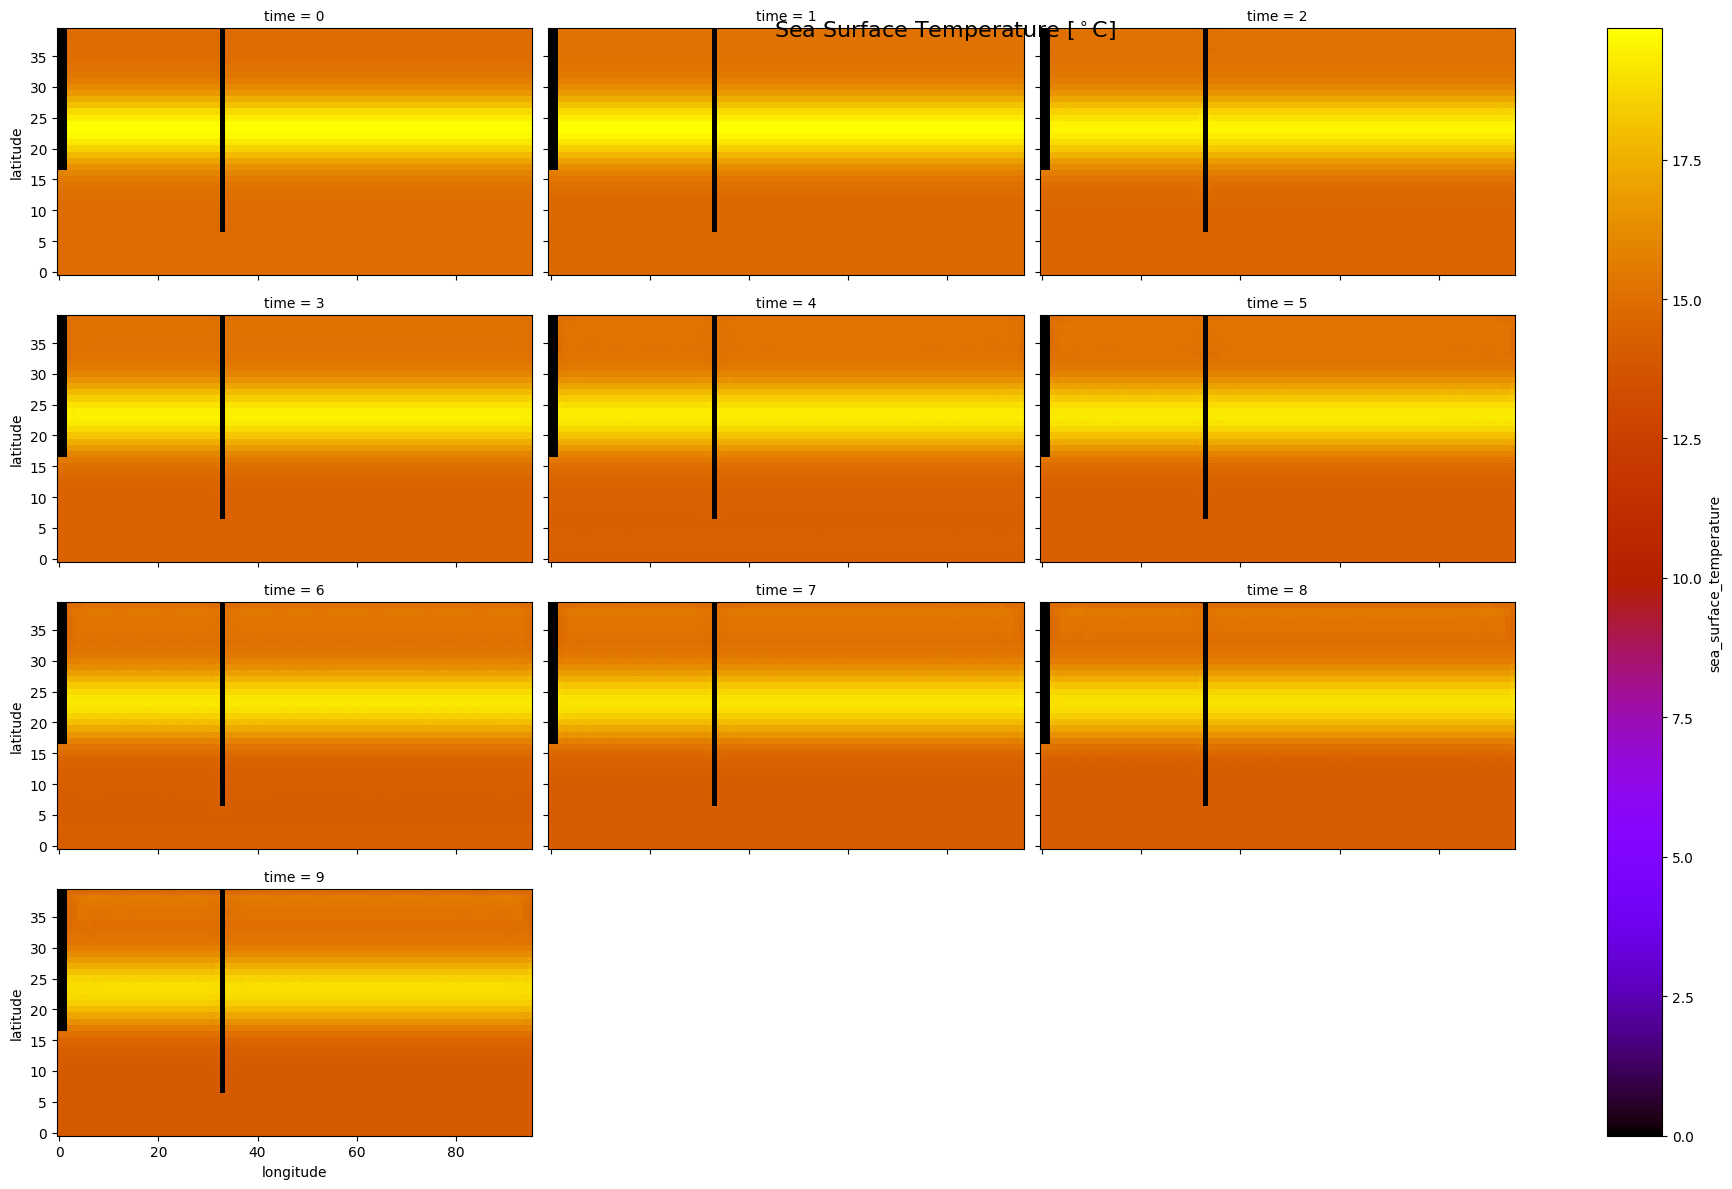

In [16]:
g = (ds['sea_surface_temperature'] - 273.15).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="gnuplot")
g.fig.suptitle("Sea Surface Temperature [${}^\\circ \\mathrm{C}$]", fontsize=16)

### Slab Ocean Model (fake land)

In [17]:
ds = output_dict["slab_ocn"]
print(str(ds))

<xarray.Dataset> Size: 1MB
Dimensions:                  (time: 10, longitude: 96, latitude: 48)
Coordinates:
  * time                     (time) float64 80B 24.0 48.0 72.0 ... 216.0 240.0
    latitude2D               (longitude, latitude) float64 37kB ...
    longitude2D              (longitude, latitude) float64 37kB ...
Dimensions without coordinates: longitude, latitude
Data variables:
    sea_surface_temperature  (time, longitude, latitude) float64 369kB ...
    mixed_layer_depth        (time, longitude, latitude) float64 369kB ...
    total_heat_flux          (time, longitude, latitude) float64 369kB ...


Text(0.5, 1.02, 'Land Surface Temperature [${}^\\circ \\mathrm{C}$]')

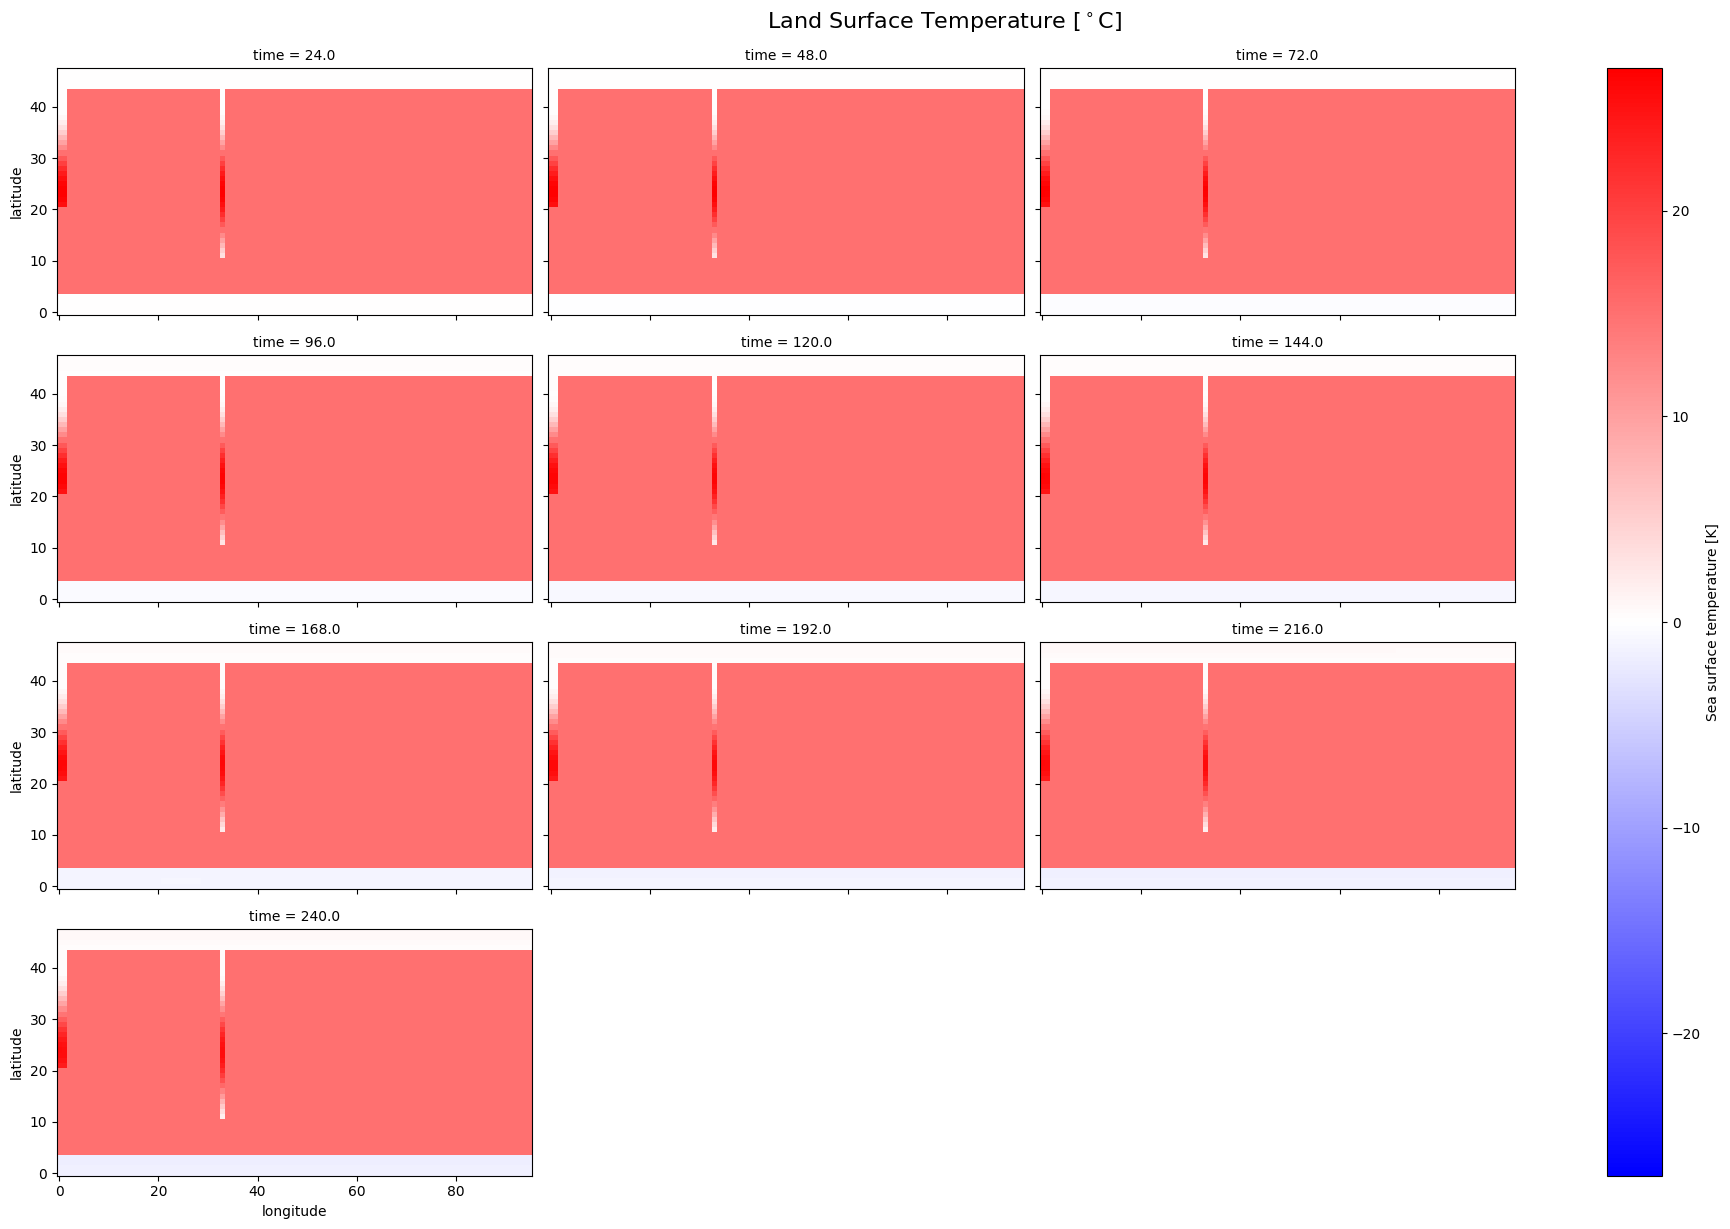

In [18]:
g = (ds['sea_surface_temperature'] - 273.15).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="bwr", center=0)
g.fig.suptitle("Land Surface Temperature [${}^\\circ \\mathrm{C}$]", fontsize=16, y=1.02)